### Importing Relevant Libraries

The necessary Python libraries are imported to support data manipulation, visualization, and system operations. NumPy and pandas are used for numerical computations and data handling, while Matplotlib and Seaborn are configured for visualization. Additional libraries such as `os`, `re`, and `time` are included for file handling, regular expressions, and performance tracking.

A fixed random seed is set to ensure reproducibility of results, particularly for any stochastic processes used later in the modelling stage.

The dataset directory is defined using an absolute path constructed via `os.path.expanduser`, ensuring portability across systems. File paths for the dataset — Selected Features was then created dynamically.

The dataset is loaded into memory using `pandas.read_csv`.

Finally, an output directory is created within the current working directory to store intermediate results, figures, and model outputs. This ensures that all generated artefacts are organized and easily accessible.

In [15]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
import os, re, time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


# Dataset path
DATA_PATH = os.path.expanduser("~/Desktop/Ireland Price Prediction")

data = os.path.join(DATA_PATH, "selected_features.csv")


# Load datasets
df = pd.read_csv(data)


print("All datasets loaded successfully")

# Output directory
WORK_DIR = os.getcwd()
OUT_DIR = os.path.join(WORK_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print("Environment ready")

All datasets loaded successfully
Environment ready


In [16]:
### Top 3 Rows

df.head(3)

,sale_date,county,price,is_new,vat_excl,is_apartment,cpi,unemployment_rate,avg_weekly_earnings
0,2010-01-01,Dublin,343000.0,0,0,1,1326.576923,17.566667,662.518333
1,2010-01-03,Laois,185000.0,1,1,1,1326.576923,17.566667,662.518333
2,2010-01-04,Tipperary,128000.0,0,0,1,1326.576923,17.566667,662.518333


## Helper Functions and Feature Utilities

This section defines reusable helper functions for data parsing, feature extraction, and model preparation.

### Date Parsing Functions
Custom parsing functions are implemented to convert CSO date formats into standard pandas datetime objects:
- `parse_cso_month`: Converts strings such as "2020 January" into monthly timestamps.
- `parse_quarter`: Converts quarterly representations into the first day of the corresponding quarter.
- `parse_half_year`: Converts half-year indicators into timestamps (January or July).

These functions ensure consistency in time-based data across datasets.

### Address Processing Functions
A set of functions is designed to extract meaningful geographic information from raw address strings:
- `_clean_addr_part`: Removes irrelevant geographic suffixes such as county names or Dublin postal references.
- `_valid_parts`: Splits addresses into components and filters out non-informative elements.
- `extract_suburb`: Identifies the most relevant location unit (typically town or suburb).
- `extract_district`: Extracts a finer-grained locality within the suburb.
- `extract_dublin_pc`: Extracts Dublin postal codes (D01–D24), which provide high spatial precision.
- `extract_eircode_routing`: Extracts the routing key (first three characters) from the Eircode.

These transformations enhance spatial granularity without requiring external geospatial data.

### Bayesian Target Encoding
The `bayesian_oof_encode` function implements an out-of-fold (OOF) Bayesian target encoding approach. This method:
- Computes group-level target means (e.g., average price per suburb)
- Applies smoothing to prevent overfitting for small groups
- Uses cross-validation to eliminate data leakage

This encoding technique is a key driver of predictive performance.

### Evaluation Metrics
The `get_metrics` function computes evaluation metrics including:
- R² (on log-transformed and original scale)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Predictions are transformed back to the original price scale for interpretability.

Overall, this section establishes the foundational tools required for preprocessing, feature engineering, and model evaluation.


In [17]:
print("="*65); print("HELPER FUNCTION"); print("="*65)


# ── CSO date parsers ──────────────────────────────────────────────
def parse_cso_month(s):
    try:    return pd.to_datetime(str(s).strip(), format="%Y %B")
    except: return pd.NaT

def parse_quarter(q):
    try:
        y, qt = int(str(q)[:4]), int(str(q)[5])
        return pd.Timestamp(year=y, month=(qt-1)*3+1, day=1)
    except: return pd.NaT

def parse_half_year(s):
    try:
        s = str(s).strip()
        return pd.Timestamp(year=int(s[:4]), month=1 if int(s[5])==1 else 7, day=1)
    except: return pd.NaT

# ── Address feature extraction ────────────────────────────────────
def _clean_addr_part(p):
    """Strip geographic suffix noise from one comma-part of an address."""
    p = p.strip().lower()
    p = re.sub(r'^\s*co\.?\s+\w+\s*$', '', p)          # whole part = 'Co. Dublin'
    p = re.sub(r'\bco\.\s*', '', p)                      # 'co.' within string
    p = re.sub(r'\bcounty\s+\w+\s*$', '', p, flags=re.I) # 'County Dublin' suffix
    p = re.sub(r'\bcounty\s*$', '', p, flags=re.I)
    p = re.sub(r',?\s*dublin\s+\d+\s*$', '', p, flags=re.I)
    p = re.sub(r'\bdublin\s+\d+\s*$', '', p, flags=re.I)
    p = re.sub(r'\s+d\d{1,2}\s*$', '', p, flags=re.I)
    return p.strip()

def _valid_parts(address, county):
    """Return cleaned, meaningful address parts."""
    county_l = str(county).strip().lower()
    if not isinstance(address, str): return []
    raw = [p.strip() for p in address.split(',')]
    result = []
    for p in raw:
        c = _clean_addr_part(p)
        if (len(c) > 2
                and not re.match(r'^\d+[a-z]?\s*$', c.replace(' ', ''))
                and c.lower() not in [county_l, '', 'co', 'co.', 'county']):
            result.append(c)
    return result

def extract_suburb(address, county):
    """Last meaningful part = suburb/town (most reliable location signal)."""
    valid = _valid_parts(address, county)
    return valid[-1] if valid else str(county).strip().lower()

def extract_district(address, county):
    """Second-to-last meaningful part = estate/district within suburb."""
    valid = _valid_parts(address, county)
    return valid[-2] if len(valid) >= 2 else extract_suburb(address, county)

def extract_dublin_pc(address, county):
    """Extract Dublin postcode (D01-D24) — most precise location for Dublin."""
    if str(county).strip().lower() != 'dublin': return 'non_dublin'
    if not isinstance(address, str): return 'dublin_unknown'
    m = re.search(r'\bD(\d{1,2})\b|\bDublin\s+(\d{1,2})\b', address, re.I)
    if m:
        return 'D' + (m.group(1) or m.group(2)).zfill(2)
    return 'dublin_unknown'

def extract_eircode_routing(eircode):
    """First 3 chars of Eircode = routing key (ultra-precise area code)."""
    if pd.isna(eircode) or str(eircode).strip() in ['', 'nan', 'NaN']:
        return 'UNKNOWN'
    return str(eircode).strip().upper()[:3]

# ── Bayesian OOF target encoder ───────────────────────────────────
def bayesian_oof_encode(df, group_col, target_col, global_mean,
                         k=30, f=1.0, n_splits=5):
    """
    Out-of-fold Bayesian smoothed mean encoding — zero data leakage.
    Groups with few samples blend toward global_mean.
    k = inflection point (k samples → 50% weight on group mean).
    """
    from sklearn.model_selection import KFold
    enc = np.full(len(df), global_mean, dtype=np.float64)
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    grp = df[group_col].values
    tgt = df[target_col].values
    for tr_idx, val_idx in kf.split(df):
        uniq, inv, counts = np.unique(grp[tr_idx], return_inverse=True, return_counts=True)
        means  = np.bincount(inv, weights=tgt[tr_idx]) / counts
        smooth = 1.0 / (1.0 + np.exp(-(counts - k) / f))
        enc_map = dict(zip(uniq, smooth * means + (1 - smooth) * global_mean))
        enc[val_idx] = np.array([enc_map.get(g, global_mean) for g in grp[val_idx]])
    return enc

# ── Metrics ───────────────────────────────────────────────────────
def get_metrics(ytl, ypl, label=""):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    yt, yp = np.expm1(ytl), np.expm1(ypl)
    return {"Model": label,
            "R² (log)": round(r2_score(ytl, ypl), 4),
            "R² (€)":   round(r2_score(yt, yp),   4),
            "MAE (€)":  round(mean_absolute_error(yt, yp), 0),
            "RMSE (€)": round(np.sqrt(mean_squared_error(yt, yp)), 0)}

print("Helpers defined.")

HELPER FUNCTION
Helpers defined.


In [18]:
# ══════════════════════════════════════════════════════════════════
# ── Section 7 — Feature Engineering (COMPLETE) ──
# ══════════════════════════════════════════════════════════════════
print("="*65); print("SECTION 7 — FEATURE ENGINEERING"); print("="*65)
t_fe = time.time()

# ── 4.1 Temporal ─────────────────────────────────────────────
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["year"]               = df["sale_date"].dt.year
df["month"]              = df["sale_date"].dt.month
df["quarter"]            = df["sale_date"].dt.quarter
df["month_sin"]          = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"]          = np.cos(2 * np.pi * df["month"] / 12)
df["quarter_sin"]        = np.sin(2 * np.pi * df["quarter"] / 4)
df["quarter_cos"]        = np.cos(2 * np.pi * df["quarter"] / 4)
df["years_since_trough"] = (df["year"] - 2012).clip(lower=0)  # Ireland trough = 2012
df["year_sq"]            = df["years_since_trough"] ** 2       # non-linear recovery

# ── 4.2 Geospatial proxy scores ───────────────────────────────
COUNTY_GEO = {
    "Dublin":    (1.00,1.00,1.00,350000), "Cork":      (0.75,0.80,0.80,240000),
    "Galway":    (0.65,0.70,0.72,220000), "Limerick":  (0.65,0.70,0.70,165000),
    "Waterford": (0.60,0.65,0.65,173000), "Wicklow":   (0.55,0.60,0.62,277000),
    "Kildare":   (0.60,0.65,0.63,248000), "Meath":     (0.55,0.58,0.60,200000),
    "Louth":     (0.55,0.58,0.60,225000), "Wexford":   (0.45,0.50,0.55,175000),
    "Kilkenny":  (0.45,0.50,0.52,175000), "Clare":     (0.45,0.48,0.52,185000),
    "Tipperary": (0.40,0.45,0.50,160000), "Kerry":     (0.40,0.42,0.50,180000),
    "Westmeath": (0.42,0.45,0.48,181000), "Offaly":    (0.38,0.40,0.45,155000),
    "Laois":     (0.38,0.42,0.45,150000), "Carlow":    (0.38,0.40,0.45,162000),
    "Sligo":     (0.42,0.44,0.48,168000), "Cavan":     (0.35,0.38,0.42,150000),
    "Monaghan":  (0.35,0.38,0.42,184000), "Longford":  (0.32,0.36,0.40,150000),
    "Roscommon": (0.30,0.35,0.40,141000), "Leitrim":   (0.28,0.32,0.38,120000),
    "Mayo":      (0.35,0.38,0.42,129000), "Donegal":   (0.35,0.38,0.42,153000),
}
_DEF = (0.45,0.48,0.50,200000)
df["urban_score"]         = df["county"].map(lambda c: COUNTY_GEO.get(c,_DEF)[0])
df["transport_score"]     = df["county"].map(lambda c: COUNTY_GEO.get(c,_DEF)[1])
df["amenity_score"]       = df["county"].map(lambda c: COUNTY_GEO.get(c,_DEF)[2])
df["county_ref_logprice"] = df["county"].map(lambda c: np.log1p(COUNTY_GEO.get(c,_DEF)[3]))
df["is_dublin"]           = (df["county"]=="Dublin").astype(int)
df["county_demand"]       = df["county"].map(df["county"].value_counts())

# ── 4.3 Address feature extraction (FIXED & IMPROVED) ────────
print("  Extracting address features…")
addr_col = df.get("address", pd.Series("", index=df.index))
df["suburb"]     = [extract_suburb(a,c)    for a,c in zip(addr_col, df["county"])]
df["district"]   = [extract_district(a,c)  for a,c in zip(addr_col, df["county"])]
df["dublin_pc"]  = [extract_dublin_pc(a,c) for a,c in zip(addr_col, df["county"])]
df["eircode_rt"] = df.get("eircode", pd.Series(np.nan, index=df.index)).map(extract_eircode_routing)
print(f"  Suburbs: {df['suburb'].nunique():,} | Districts: {df['district'].nunique():,} | Dublin PCs: {df['dublin_pc'].nunique()} | Eircode RTs: {df['eircode_rt'].nunique():,}")

# ── 4.4 Group interaction keys ────────────────────────────────
df["year_county"]    = df["year"].astype(str) + "_" + df["county"]
df["year_suburb"]    = df["year"].astype(str) + "_" + df["suburb"]
df["year_district"]  = df["year"].astype(str) + "_" + df["district"]
df["qtr_county"]     = df["quarter"].astype(str) + "Q" + df["year"].astype(str) + "_" + df["county"]
df["type_suburb"]    = df["is_new"].astype(str) + "_" + df["suburb"]
df["apt_suburb"]     = df["is_apartment"].astype(str) + "_" + df["suburb"]
df["type_county"]    = df["is_new"].astype(str) + "_" + df["county"]
df["dublin_pc_type"] = df["dublin_pc"] + "_" + df["is_new"].astype(str)

# ── 4.5 Log-transform target ──────────────────────────────────
df["log_price"]    = np.log1p(df["price"])
GLOBAL_LOG_MEAN    = df["log_price"].mean()
print(f"  Global log-price mean: {GLOBAL_LOG_MEAN:.4f}")

# ── 4.6 Bayesian OOF target encodings ────────────────────────
# Hierarchy: eircode (finest) → district → suburb → dublin_pc → county
# Each encoding captures location price premium at a different granularity
print("  Computing OOF Bayesian encodings…")
enc_t = time.time()

# k = minimum samples for 50% weight on group mean
# Lower k = trust small groups more (fine for granular features)
encode_specs = [
    # (output,              group,           k,   desc)
    ("county_enc",          "county",        50,  "county"),
    ("suburb_enc",          "suburb",        15,  "suburb"),
    ("district_enc",        "district",      8,   "district/estate"),
    ("eircode_enc",         "eircode_rt",    10,  "eircode routing key"),
    ("dublin_pc_enc",       "dublin_pc",     15,  "Dublin postcode"),
    ("year_county_enc",     "year_county",   30,  "county × year"),
    ("year_suburb_enc",     "year_suburb",   8,   "suburb × year"),
    ("year_district_enc",   "year_district", 5,   "district × year"),
    ("qtr_county_enc",      "qtr_county",    20,  "county × quarter"),
    ("type_suburb_enc",     "type_suburb",   8,   "new/2nd-hand × suburb"),
    ("apt_suburb_enc",      "apt_suburb",    8,   "apt/house × suburb"),
    ("type_county_enc",     "type_county",   20,  "new/2nd-hand × county"),
    ("dublin_pc_type_enc",  "dublin_pc_type",10,  "Dublin PC × type"),
]

for out_col, grp_col, k, desc in encode_specs:
    df[out_col] = bayesian_oof_encode(df, grp_col, "log_price", GLOBAL_LOG_MEAN, k=k, f=1.0, n_splits=5)
    corr = df[out_col].corr(df["log_price"])
    print(f"    {desc:<32} r = {corr:.4f}")

print(f"  Encodings done in {time.time()-enc_t:.1f}s")

# ── 4.7 Composite location score ─────────────────────────────
# Blend fine→coarse encodings: eircode > district > suburb > county
# On rows where eircode is known, it dominates; else suburb/county
eircode_known = df["eircode_enc"] != GLOBAL_LOG_MEAN
df["location_score"] = np.where(
    eircode_known,
    0.50*df["eircode_enc"]    + 0.25*df["district_enc"]  + 0.15*df["suburb_enc"] + 0.10*df["county_enc"],
    0.40*df["district_enc"]   + 0.35*df["suburb_enc"]    + 0.25*df["county_enc"]
)
# Dublin-specific: blend with dublin_pc
dublin_known = df["dublin_pc"] != "non_dublin"
df.loc[dublin_known, "location_score"] = (
    0.40*df.loc[dublin_known,"dublin_pc_enc"]   +
    0.30*df.loc[dublin_known,"suburb_enc"]      +
    0.20*df.loc[dublin_known,"district_enc"]    +
    0.10*df.loc[dublin_known,"county_enc"]
)
print(f"  location_score corr: {df['location_score'].corr(df['log_price']):.4f}")

# ── 4.8 Macroeconomic lags & momentum ────────────────────────
for col, lags in [("cpi",[1,3,6,12]),("unemployment_rate",[1,3,6]),("avg_weekly_earnings",[1,3,6])]:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)
lag_cols = [c for c in df.columns if "_lag" in c]
df[lag_cols] = df[lag_cols].ffill().bfill()
df["cpi_yoy"]         = df["cpi"]               - df.get("cpi_lag12", df["cpi"])
df["unemp_change_6m"] = df["unemployment_rate"] - df["unemployment_rate_lag6"]
df["earn_change_6m"]  = df["avg_weekly_earnings"]- df["avg_weekly_earnings_lag6"]

# ── 4.9 Interaction features ──────────────────────────────────
df["new_x_dublin"]       = df["is_new"]       * df["is_dublin"]
df["apt_x_dublin"]       = df["is_apartment"] * df["is_dublin"]

# size_cat removed → fallback to urban_score only
df["size_x_urban"]       = df["urban_score"]

# Safe VAT interaction
df["vat_x_new"]          = df["vat_excl"] * df["is_new"] if "vat_excl" in df.columns else df["is_new"]

df["loc_x_recovery"]     = df["location_score"]   * df["years_since_trough"]
df["suburb_x_recovery"]  = df["suburb_enc"]       * df["years_since_trough"]
df["county_x_recovery"]  = df["year_county_enc"]  * df["years_since_trough"]
df["loc_x_new"]          = df["location_score"]   * df["is_new"]
df["loc_x_apt"]          = df["location_score"]   * df["is_apartment"]
df["unemp_x_location"]   = df["unemployment_rate"]* df["location_score"]
df["earn_x_location"]    = df["avg_weekly_earnings"] * df["location_score"] / 1000

# ── 4.10 Rolling market momentum ─────────────────────────────
df_s = df.sort_values("sale_date")
for window, min_p in [(90,10),(180,20),(365,30)]:
    col_name = f"county_roll_{window}d"
    df[col_name] = (df_s.groupby("county")["log_price"]
                    .transform(lambda x: x.shift(1).rolling(window, min_periods=min_p).median())
                    .values)
    df[col_name] = df[col_name].fillna(df["county_enc"])

# Suburb rolling (180-day) — captures local momentum
df["suburb_roll_180d"] = (df_s.groupby("suburb")["log_price"]
                          .transform(lambda x: x.shift(1).rolling(180, min_periods=5).median())
                          .values)
df["suburb_roll_180d"] = df["suburb_roll_180d"].fillna(df["suburb_enc"])

print(f"\n  Total FE time: {time.time()-t_fe:.1f}s")
print(f"  Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Log-price skewness: {df['log_price'].skew():.3f}")
print("Section 7 complete")

SECTION 7 — FEATURE ENGINEERING
  Extracting address features…
  Suburbs: 26 | Districts: 26 | Dublin PCs: 2 | Eircode RTs: 1
  Global log-price mean: 12.3265
  Computing OOF Bayesian encodings…
    county                           r = 0.5146
    suburb                           r = 0.5146
    district/estate                  r = 0.5146
    eircode routing key              r = -0.0008
    Dublin postcode                  r = 0.4124
    county × year                    r = 0.6330
    suburb × year                    r = 0.6330
    district × year                  r = 0.6330
    county × quarter                 r = 0.6345
    new/2nd-hand × suburb            r = 0.5243
    apt/house × suburb               r = 0.5146
    new/2nd-hand × county            r = 0.5243
    Dublin PC × type                 r = 0.4366
  Encodings done in 64.1s
  location_score corr: 0.5017

  Total FE time: 113.8s
  Dataset: 736,002 rows × 79 cols
  Log-price skewness: -0.305
Section 7 complete


PHASE 5 — EXPLORATORY DATA ANALYSIS


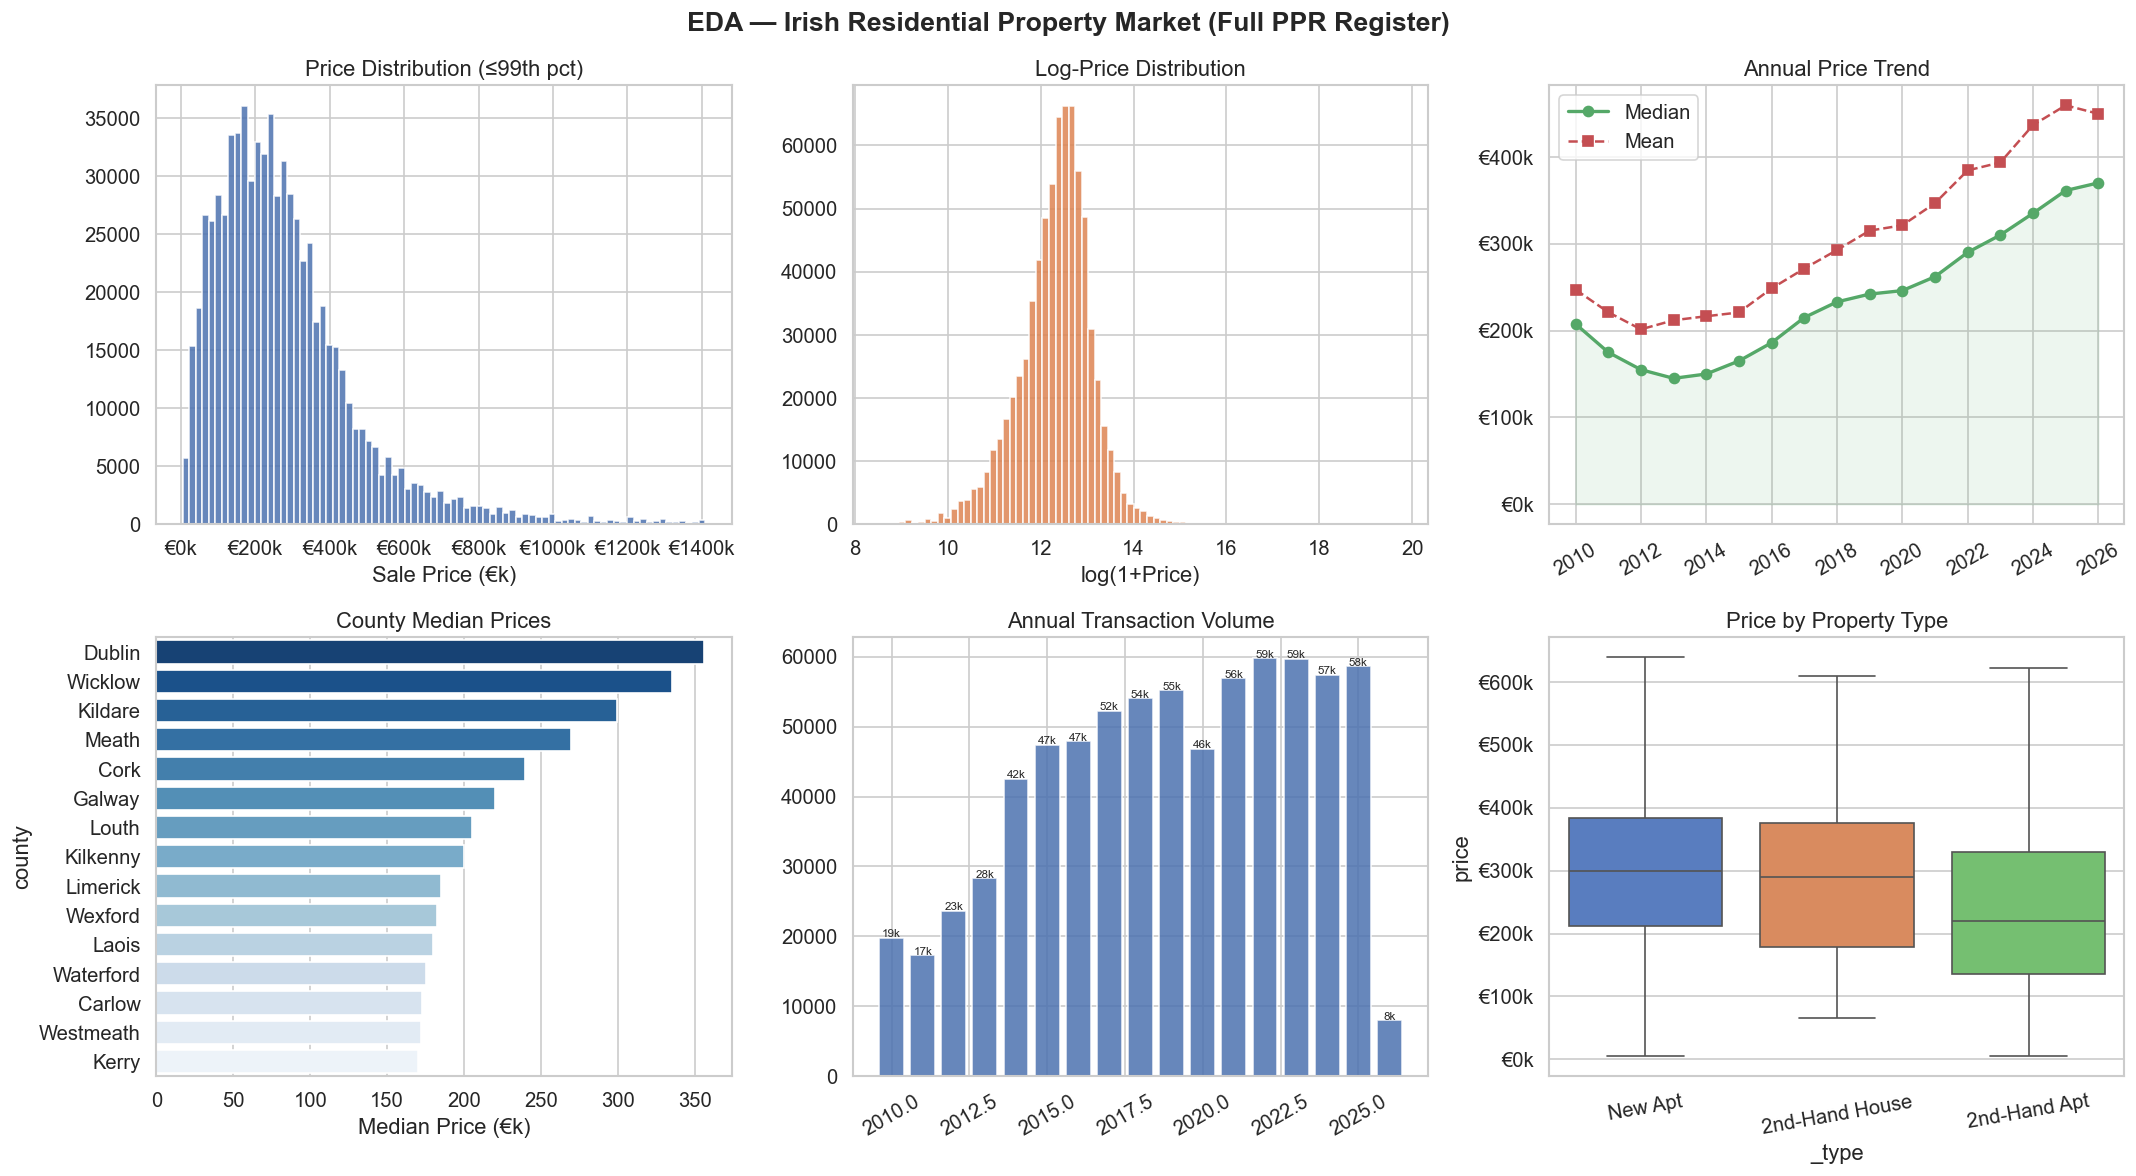

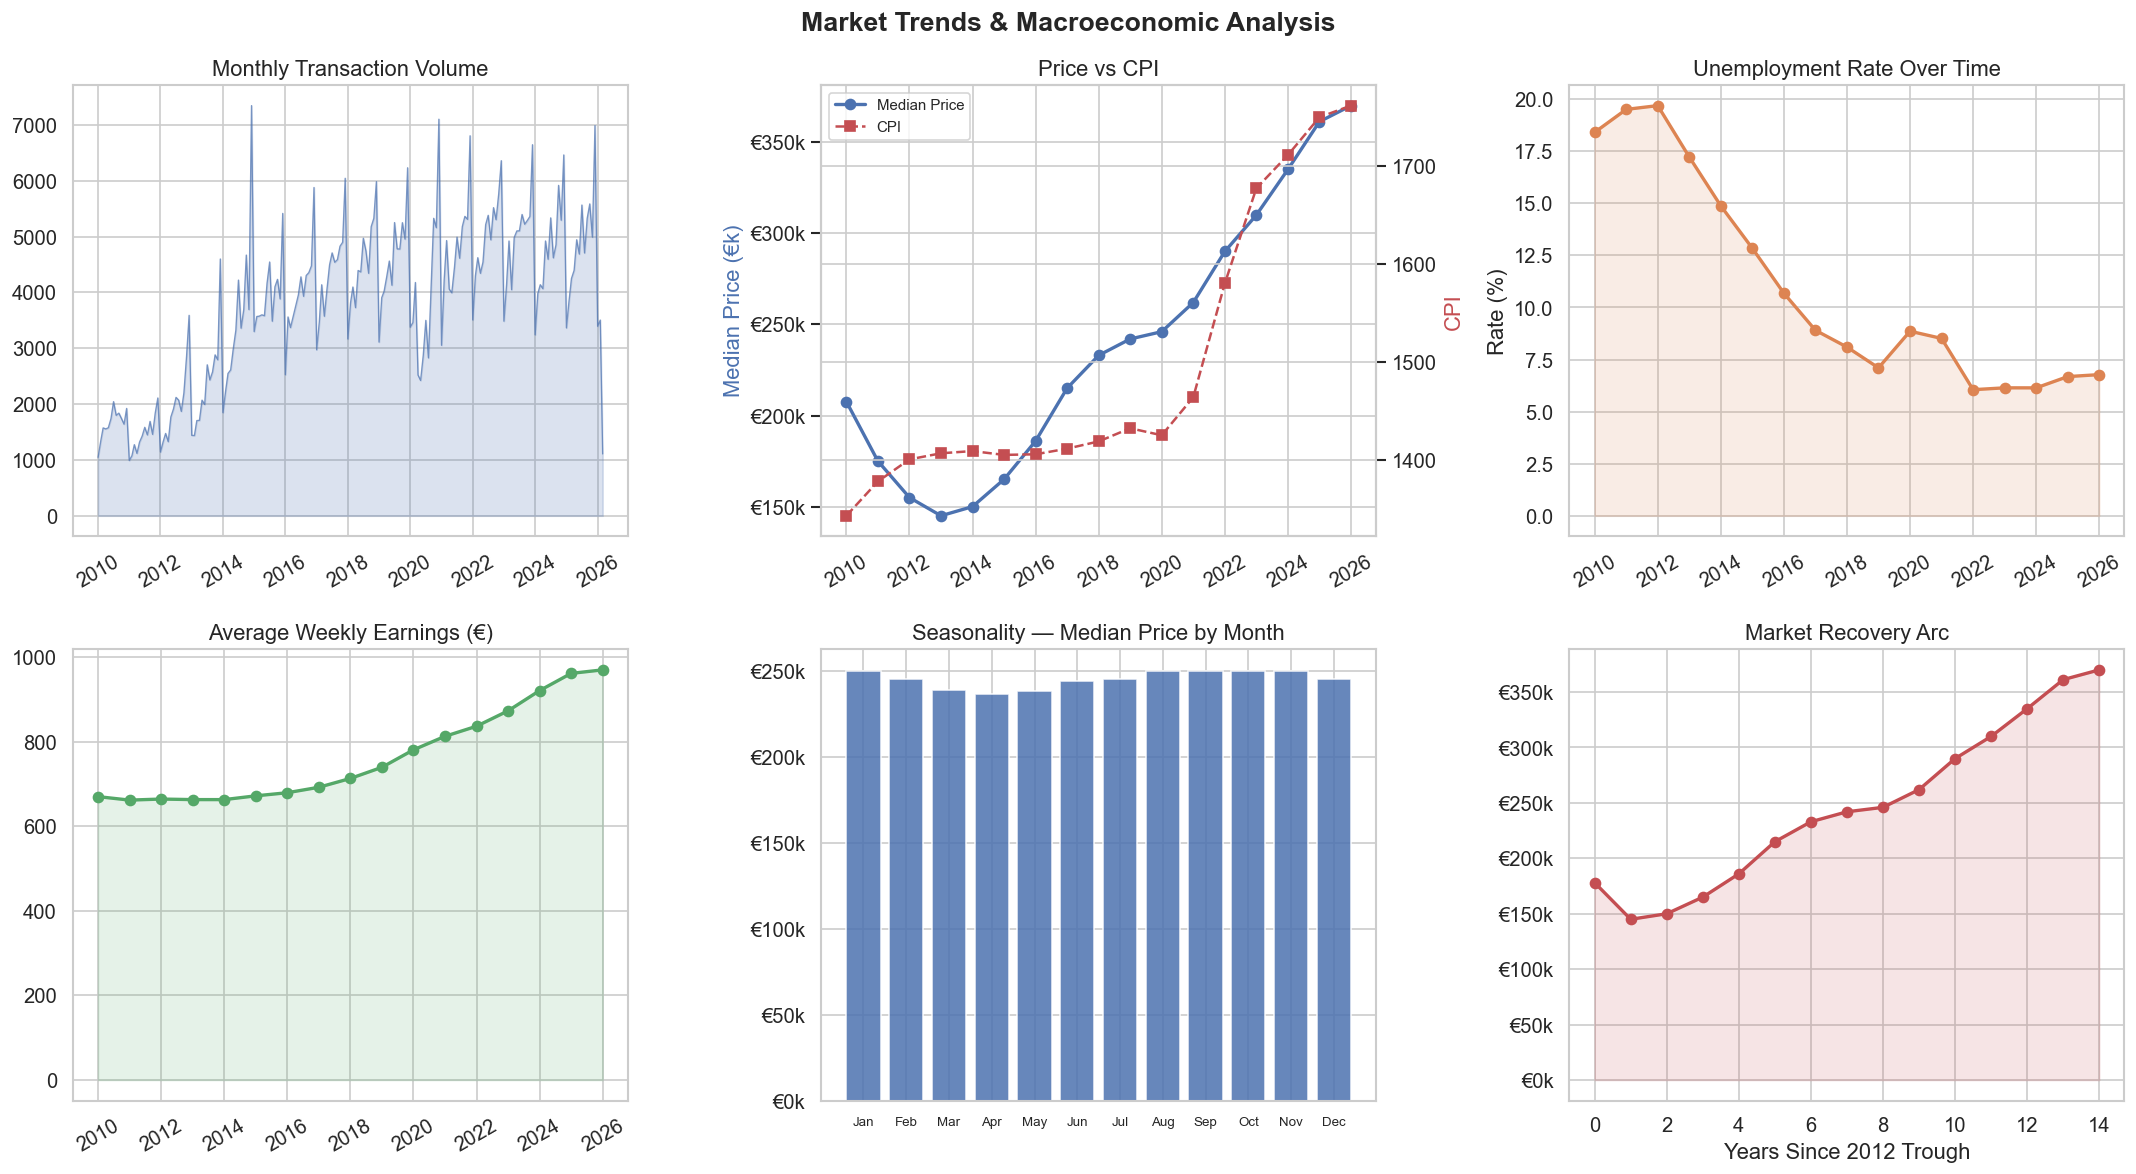

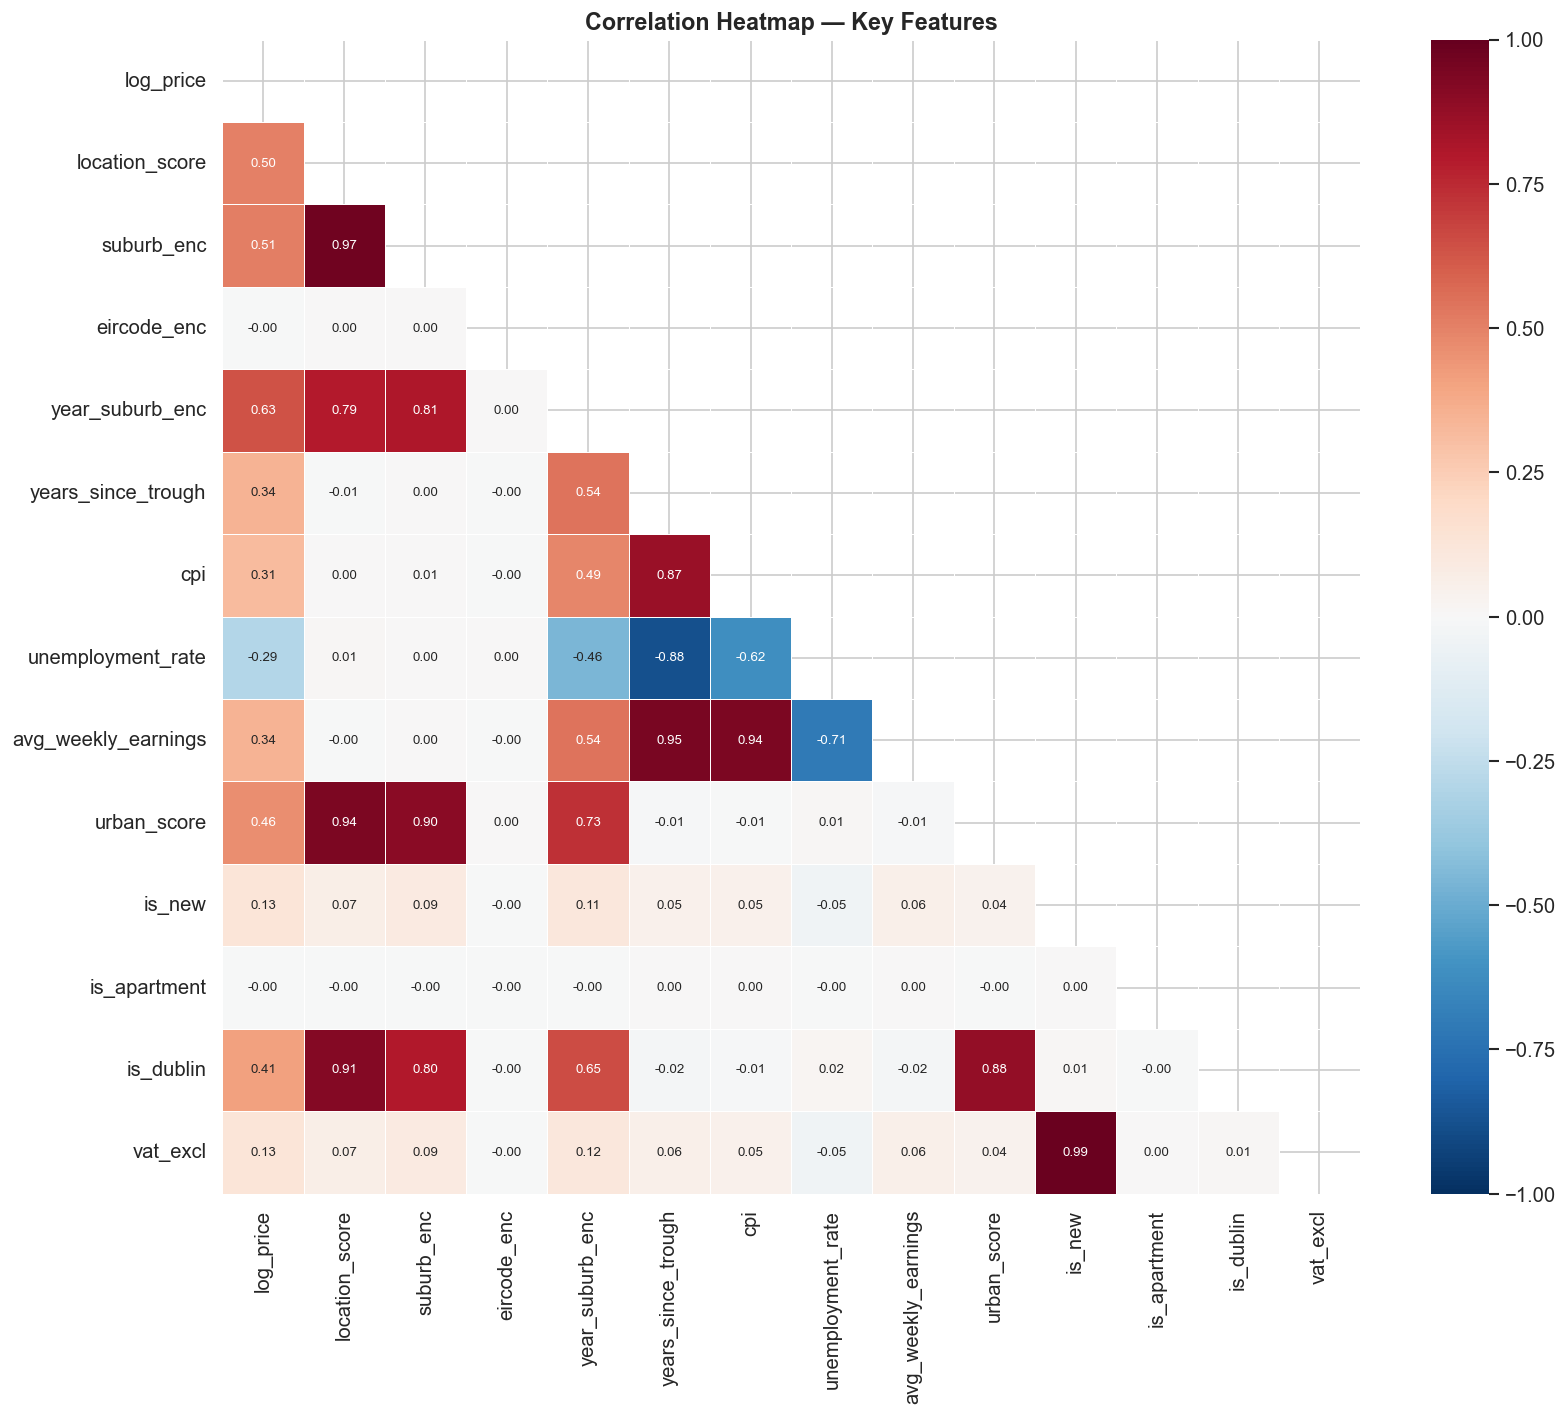

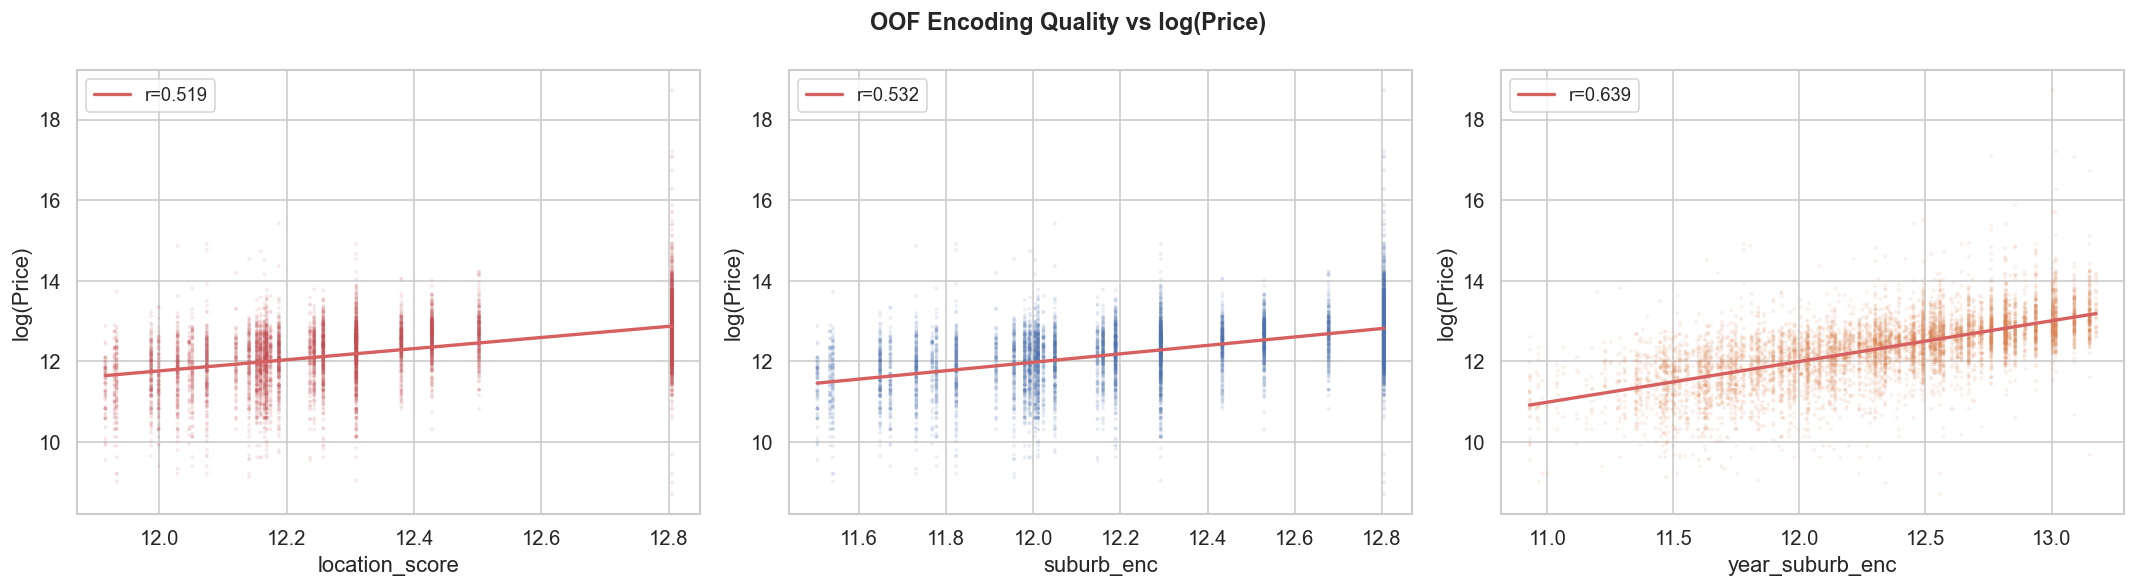

IQR bounds: €-177,500 — €690,500
Outliers  : 38,309 rows (5.2%)


,price(€)
count,7.360020e+05
mean,3.198028e+05
std,1.151949e+06
min,5.030530e+03
25%,1.480000e+05
50%,2.450000e+05
75%,3.650000e+05
max,3.876652e+08


Section 8 complete


In [19]:
# ══════════════════════════════════════════════════════════════════
# ── Section 8 EDA ──
# ══════════════════════════════════════════════════════════════════
print("="*65); print("SECTION 8 — EXPLORATORY DATA ANALYSIS"); print("="*65)

# ── Fig 1: Price Overview ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18,10))
fig.suptitle("EDA — Irish Residential Property Market (Full PPR Register)",
             fontsize=16, fontweight="bold")

clip99 = df["price"].quantile(0.99)
ax=axes[0,0]
ax.hist(df[df["price"]<=clip99]["price"]/1e3, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_xlabel("Sale Price (€k)"); ax.set_title("Price Distribution (≤99th pct)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:.0f}k"))

ax=axes[0,1]
ax.hist(df["log_price"], bins=80, color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_xlabel("log(1+Price)"); ax.set_title("Log-Price Distribution")

ax=axes[0,2]
yr = df.groupby("year")["price"].agg(["median","mean"])/1e3
ax.plot(yr.index, yr["median"], "o-", color="#55A868", lw=2, label="Median")
ax.plot(yr.index, yr["mean"],   "s--",color="#C44E52", lw=1.5, label="Mean")
ax.fill_between(yr.index, yr["median"], alpha=0.1, color="#55A868")
ax.set_title("Annual Price Trend"); ax.legend(); ax.tick_params(axis="x",rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:.0f}k"))

ax=axes[1,0]
top_c = df.groupby("county")["price"].median().sort_values(ascending=False).head(15)/1e3
sns.barplot(x=top_c.values, y=top_c.index, ax=ax, palette="Blues_r", orient="h")
ax.set_xlabel("Median Price (€k)"); ax.set_title("County Median Prices")

ax=axes[1,1]
vol = df.groupby("year").size()
bars=ax.bar(vol.index, vol.values, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.set_title("Annual Transaction Volume")
for bar,v in zip(bars,vol.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f"{v//1000:.0f}k", ha="center", fontsize=7)
ax.tick_params(axis="x",rotation=30)

ax=axes[1,2]
clip_box = df["price"].quantile(0.95)
df["_type"] = df["is_new"].map({1:"New",0:"2nd-Hand"})+" "+df["is_apartment"].map({1:"Apt",0:"House"})
order_ = df.groupby("_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df[df["price"]<=clip_box], x="_type", y="price", order=order_,
            ax=ax, palette="muted", showfliers=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x/1e3:.0f}k"))
ax.set_title("Price by Property Type"); ax.tick_params(axis="x",rotation=10)
df.drop(columns=["_type"], inplace=True, errors="ignore")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"eda_overview.png"), bbox_inches="tight"); plt.show()

# ── Fig 2: Market Trends ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18,10))
fig.suptitle("Market Trends & Macroeconomic Analysis", fontsize=16, fontweight="bold")

ax=axes[0,0]
mv = df.groupby(["year","month"]).size().reset_index(name="n")
mv["dt"] = pd.to_datetime(mv["year"].astype(str)+"-"+mv["month"].astype(str)+"-01")
ax.plot(mv["dt"], mv["n"], color="#4C72B0", lw=0.8, alpha=0.7)
ax.fill_between(mv["dt"], mv["n"], alpha=0.2, color="#4C72B0")
ax.set_title("Monthly Transaction Volume"); ax.tick_params(axis="x",rotation=30)

ax=axes[0,1]; ax2_=ax.twinx()
my = df.groupby("year").agg(med=("price","median"), cpi=("cpi","mean")).reset_index()
ax.plot(my["year"], my["med"]/1e3, "o-", color="#4C72B0", lw=2, label="Median Price")
ax2_.plot(my["year"], my["cpi"], "s--", color="#C44E52", lw=1.5, label="CPI")
ax.set_ylabel("Median Price (€k)", color="#4C72B0"); ax2_.set_ylabel("CPI", color="#C44E52")
ax.set_title("Price vs CPI"); ax.tick_params(axis="x",rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:.0f}k"))
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2_.get_legend_handles_labels()
ax.legend(l1+l2,lb1+lb2,fontsize=9)

ax=axes[0,2]
uy = df.groupby("year")["unemployment_rate"].mean()
ax.plot(uy.index, uy.values, "o-", color="#DD8452", lw=2)
ax.fill_between(uy.index, uy.values, alpha=0.15, color="#DD8452")
ax.set_title("Unemployment Rate Over Time"); ax.set_ylabel("Rate (%)")
ax.tick_params(axis="x",rotation=30)

ax=axes[1,0]
ey = df.groupby("year")["avg_weekly_earnings"].mean()
ax.plot(ey.index, ey.values, "o-", color="#55A868", lw=2)
ax.fill_between(ey.index, ey.values, alpha=0.15, color="#55A868")
ax.set_title("Average Weekly Earnings (€)"); ax.tick_params(axis="x",rotation=30)

ax=axes[1,1]
sm = df.groupby("month")["price"].median()/1e3
ax.bar(range(1,13), sm.values, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.set_title("Seasonality — Median Price by Month"); ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:.0f}k"))

ax=axes[1,2]
tr = df.groupby("years_since_trough")["price"].median()/1e3
ax.plot(tr.index, tr.values, "o-", color="#C44E52", lw=2)
ax.fill_between(tr.index, tr.values, alpha=0.15, color="#C44E52")
ax.set_xlabel("Years Since 2012 Trough"); ax.set_title("Market Recovery Arc")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:.0f}k"))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"eda_trends.png"), bbox_inches="tight"); plt.show()

# ── Fig 3: Correlation Heatmap ────────────────────────────────
key = ["log_price","location_score","suburb_enc","eircode_enc","year_suburb_enc",
       "years_since_trough","cpi","unemployment_rate","avg_weekly_earnings",
       "urban_score","is_new","is_apartment","is_dublin","size_cat","vat_excl"]
key = [c for c in key if c in df.columns]
corr = df[key].corr()
fig, ax = plt.subplots(figsize=(14,12))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.4, annot_kws={"size":8})
ax.set_title("Correlation Heatmap — Key Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"eda_correlation.png"), bbox_inches="tight"); plt.show()

# ── Fig 4: Encoding Quality ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle("OOF Encoding Quality vs log(Price)", fontsize=14, fontweight="bold")
sample = df.sample(min(8000,len(df)), random_state=42)
for ax, col, color in zip(axes,
    ["location_score","suburb_enc","year_suburb_enc"],
    ["#C44E52","#4C72B0","#DD8452"]):
    if col in df.columns:
        ax.scatter(sample[col], sample["log_price"], alpha=0.12, s=5, color=color, edgecolors="none")
        z = np.polyfit(sample[col].fillna(sample[col].median()), sample["log_price"], 1)
        xl = np.linspace(sample[col].min(), sample[col].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), "r-", lw=2, label=f"r={sample[col].corr(sample['log_price']):.3f}")
        ax.set_xlabel(col); ax.set_ylabel("log(Price)"); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"eda_encoding_quality.png"), bbox_inches="tight"); plt.show()

# ── Outlier summary ───────────────────────────────────────────
Q1,Q3 = df["price"].quantile(0.25), df["price"].quantile(0.75); IQR=Q3-Q1
outliers = df[(df["price"]<Q1-1.5*IQR)|(df["price"]>Q3+1.5*IQR)]
print(f"IQR bounds: €{Q1-1.5*IQR:,.0f} — €{Q3+1.5*IQR:,.0f}")
print(f"Outliers  : {len(outliers):,} rows ({100*len(outliers)/len(df):.1f}%)")
display(df["price"].describe().rename("price(€)").to_frame())
print("Section 8 complete")